In [1]:
from typing import List, Tuple
import time
from wav2vec2decoder import Wav2Vec2Decoder
import time
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import kenlm
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import Levenshtein
from torch.utils.data import Dataset
from wav2vec2decoder import Wav2Vec2Decoder
from jiwer import wer, cer
import Levenshtein

In [2]:
test_samples = [
        ("examples/sample1.wav", "IF YOU ARE GENEROUS HERE IS A FITTING OPPORTUNITY FOR THE EXERCISE OF YOUR MAGNANIMITY IF YOU ARE PROUD HERE AM I YOUR RIVAL READY TO ACKNOWLEDGE MYSELF YOUR DEBTOR FOR AN ACT OF THE MOST NOBLE FORBEARANCE"),
        ("examples/sample2.wav", "AND IF ANY OF THE OTHER COPS HAD PRIVATE RACKETS OF THEIR OWN IZZY WAS UNDOUBTEDLY THE MAN TO FIND IT OUT AND USE THE INFORMATION WITH A BEAT SUCH AS THAT EVEN GOING HALVES AND WITH ALL THE GRAFT TO THE UPPER BRACKETS HE'D STILL BE ABLE TO MAKE HIS PILE IN A MATTER OF MONTHS"),
        ("examples/sample3.wav", "GUESS A MAN GETS USED TO ANYTHING HELL MAYBE I CAN HIRE SOME BUMS TO SIT AROUND AND WHOOP IT UP WHEN THE SHIPS COME IN AND BILL THIS AS A REAL OLD MARTIAN DEN OF SIN"),
        ("examples/sample4.wav", "IT WAS A TUNE THEY HAD ALL HEARD HUNDREDS OF TIMES SO THERE WAS NO DIFFICULTY IN TURNING OUT A PASSABLE IMITATION OF IT TO THE IMPROVISED STRAINS OF I DIDN'T WANT TO DO IT THE PRISONER STRODE FORTH TO FREEDOM"),
        ("examples/sample5.wav", "MARGUERITE TIRED OUT WITH THIS LONG CONFESSION THREW HERSELF BACK ON THE SOFA AND TO STIFLE A SLIGHT COUGH PUT UP HER HANDKERCHIEF TO HER LIPS AND FROM THAT TO HER EYES"),
        ("examples/sample6.wav", "AT THIS TIME ALL PARTICIPANTS ARE IN A LISTEN ONLY MODE"),
        ("examples/sample7.wav", "THE INCREASE WAS MAINLY ATTRIBUTABLE TO THE NET INCREASE IN THE AVERAGE SIZE OF OUR FLEETS"),
        ("examples/sample8.wav", "OPERATING SURPLUS IS A NON CAP FINANCIAL MEASURE WHICH IS DEFINED AS FULLY IN OUR PRESS RELEASE"),
    ]

In [3]:
audio_path, true_transcription = test_samples[0]
audio_input, sr = torchaudio.load(audio_path)
print(true_transcription.lower())

if you are generous here is a fitting opportunity for the exercise of your magnanimity if you are proud here am i your rival ready to acknowledge myself your debtor for an act of the most noble forbearance


# Dataset

In [4]:
class LibriSpeechDataset(Dataset):
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        waveform, sample_rate = torchaudio.load(row['path'])
        text = row['text']
        return waveform, sample_rate, text

In [5]:
dataset = LibriSpeechDataset('data/librispeech_test_other/manifest.csv')

# Таска 1

In [6]:
decoder = Wav2Vec2Decoder()
inputs = decoder.processor(audio_input[0], sampling_rate=sr,  return_tensors="pt")
with torch.no_grad():
    probs = decoder.model(**inputs).logits
greedy_decode = decoder.greedy_decode(probs)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [6]:
def evaluate(decoder, dataset, method="greedy"):
    all_refs, all_hyps = [], []

    start = time.time()
    for waveform, sample_rate, ref_text in dataset:
        assert sample_rate == 16000, f"Expected 16kHz, got {sample_rate}"
        hyp = decoder.decode(waveform.squeeze(), method=method)

        all_refs.append(ref_text.lower().strip())
        all_hyps.append(hyp.lower().strip())

    elapsed = time.time() - start
    return wer(all_refs, all_hyps), cer(all_refs, all_hyps), elapsed


In [8]:
# Greedy
decoder = Wav2Vec2Decoder(beam_width=1)
greedy_wer, greedy_cer, greedy_time = evaluate(decoder, dataset, method="greedy")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [9]:
print(f" WER: {greedy_wer*100:.2f}% (реф = 10.4%)")
print(f" CER: {greedy_cer*100:.2f}% (реф = 3.5%)")

 WER: 11.22% (реф = 10.4%)
 CER: 3.81% (реф = 3.5%)


# Таска 2

In [10]:
# Beam k=3
decoder = Wav2Vec2Decoder(beam_width=3)
beam_wer, beam_cer, beam_time = evaluate(decoder, dataset, method="beam")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [11]:
print(f" WER: {beam_wer*100:.2f}% (реф = 9.9%)")
print(f" CER: {beam_cer*100:.2f}% (реф = 3.4%)")

 WER: 11.15% (реф = 9.9%)
 CER: 3.78% (реф = 3.4%)


In [15]:
# перебор по колчиеству луче
results = []
decoder = Wav2Vec2Decoder()
for k in [1, 3, 10, 50]:
    decoder.beam_width=k
    w, c, t = evaluate(decoder, dataset, method="beam")
    results.append({"beam_width": k, "WER": w*100, "CER": c*100, "time_sec": t})
    print(f"k={k:>2}  WER={w*100:.2f}%  CER={c*100:.2f}%  time={t:.1f}s")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


k= 1  WER=11.24%  CER=3.80%  time=81.1s
k= 3  WER=11.15%  CER=3.78%  time=89.2s
k=10  WER=11.07%  CER=3.77%  time=135.1s
k=50  WER=11.10%  CER=3.77%  time=421.4s


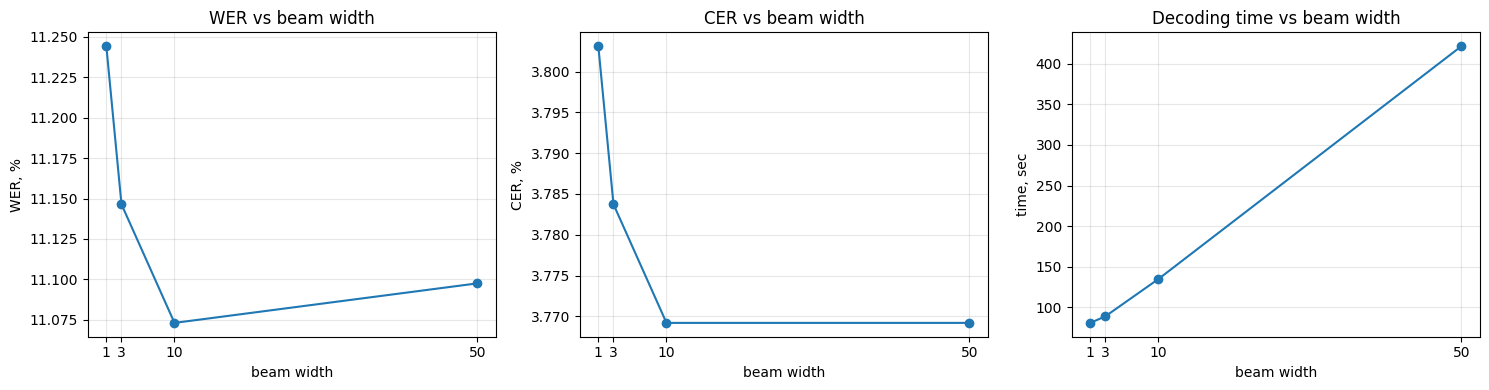

In [16]:
ks = [r["beam_width"] for r in results]
wers = [r["WER"] for r in results]
cers = [r["CER"] for r in results]
times = [r["time_sec"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, wers, marker="o")
axes[0].set_title("WER vs beam width")
axes[0].set_xlabel("beam width")
axes[0].set_ylabel("WER, %")
axes[0].set_xticks(ks)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ks, cers, marker="o")
axes[1].set_title("CER vs beam width")
axes[1].set_xlabel("beam width")
axes[1].set_ylabel("CER, %")
axes[1].set_xticks(ks)
axes[1].grid(True, alpha=0.3)

axes[2].plot(ks, times, marker="o")
axes[2].set_title("Decoding time vs beam width")
axes[2].set_xlabel("beam width")
axes[2].set_ylabel("time, sec")
axes[2].set_xticks(ks)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Таска 3

In [8]:
# перебор по колчиеству луче
results = []
decoder = Wav2Vec2Decoder(beam_width=10)
for temp in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    decoder.temperature=temp
    w, c, t = evaluate(decoder, dataset, method="greedy")
    results.append({"temperature": temp, "WER": w*100, "CER": c*100, "time_sec": t})
    print(f"temp={temp}  WER={w*100:.2f}%  CER={c*100:.2f}%  time={t:.1f}s")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


temp=0.5  WER=11.22%  CER=3.81%  time=84.3s
temp=0.8  WER=11.22%  CER=3.81%  time=85.5s
temp=1.0  WER=11.22%  CER=3.81%  time=89.0s
temp=1.2  WER=11.22%  CER=3.81%  time=87.7s
temp=1.5  WER=11.22%  CER=3.81%  time=84.9s
temp=2.0  WER=11.22%  CER=3.81%  time=82.9s


# Таска 4

In [22]:
# тест на 10 лучевом декоделе + ЛМ
decoder = Wav2Vec2Decoder(beam_width=10)
inputs = decoder.processor(audio_input[0], sampling_rate=sr,  return_tensors="pt")
with torch.no_grad():
    probs = decoder.model(**inputs).logits
decoder.beam_search_with_lm(probs)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


'if you are generous here is a fiting opportunity for the exercise of your menanimity if you are proud here am i ar rival rather toknowledge myself your diptor for an act of the most noble forbarans'

In [29]:
# Beam k=10
decoder = Wav2Vec2Decoder(beam_width=10)
beam_wer, beam_cer, beam_time = evaluate(decoder, dataset, method="beam_lm")
print(f" WER: {beam_wer*100:.2f}% (реф = 9.7%)")
print(f" CER: {beam_cer*100:.2f}% (реф = 3.4%)")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


 WER: 11.27% (реф = 9.7%)
 CER: 3.80% (реф = 3.4%)


In [7]:
def show_table(result):
    df = pd.DataFrame(result).copy()
    
    df["WER"] = df["WER"].round(2)
    df["CER"] = df["CER"].round(2)
    
    # сортировка
    df_sorted = df.sort_values(["CER", "WER"]).reset_index(drop=True)
    
    top5 = df_sorted.head(5).reset_index(drop=True)
    bottom5 = df_sorted.tail(5).sort_values(["CER", "WER"]).reset_index(drop=True)
    
    top5 = top5.rename(columns={
        "alpha": "Alpha",
        "beta": "Beta",
        "WER": "WER",
        "CER": "CER",
        "time_sec": "Time"
    })
    
    bottom5 = bottom5.rename(columns={
        "alpha": "Alpha",
        "beta": "Beta",
        "WER": "WER",
        "CER": "CER",
        "time_sec": "Time"
    })
    
    top5.columns = ["Top_" + c for c in top5.columns]
    bottom5.columns = ["Bot_" + c for c in bottom5.columns]
    
    final_table = pd.concat([top5, bottom5], axis=1)
    
    def style_table(df):
        styles = pd.DataFrame("", index=df.index, columns=df.columns)
    
        # заливка
        for col in df.columns:
            if col.startswith("Top_"):
                styles[col] = "background-color: #e8f5e9;"
            elif col.startswith("Bot_"):
                styles[col] = "background-color: #fdecea;"
    
        # лучшая строка
        top_cols = [c for c in df.columns if c.startswith("Top_")]
        styles.loc[0, top_cols] = "background-color: #81c784; font-weight: bold;"
    
        # худшая строка
        bot_cols = [c for c in df.columns if c.startswith("Bot_")]
        styles.loc[4, bot_cols] = "background-color: #e57373; font-weight: bold;"
    
        return styles
    
    styled = (
        final_table.style
        .apply(style_table, axis=None)
        .format({
            col: "{:.2f}" for col in final_table.columns if final_table[col].dtype != "object"
        })
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #ddd",
            "padding": "4px"
        })
    )

    return styled

In [24]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

results_lm = []

for alpha in alphas:
    for beta in betas:
        decoder.alpha=alpha
        decoder.beta=beta
        w, c, t = evaluate(decoder, dataset, method="beam_lm")

        row = {
            "alpha": alpha,
            "beta": beta,
            "WER": w * 100,
            "CER": c * 100,
            "time": t
        }
        results_lm.append(row)

        print(
            f"alpha={alpha:<4} beta={beta:<3} "
            f"WER={w*100:.2f}% CER={c*100:.2f}% time={t:.1f}s"
        )

alpha=0.01 beta=0.0 WER=11.07% CER=3.77% time=239.9s
alpha=0.01 beta=0.5 WER=11.05% CER=3.76% time=241.6s
alpha=0.01 beta=1.0 WER=11.22% CER=3.79% time=243.1s
alpha=0.01 beta=1.5 WER=11.32% CER=3.79% time=245.5s
alpha=0.05 beta=0.0 WER=11.02% CER=3.76% time=242.9s
alpha=0.05 beta=0.5 WER=11.05% CER=3.75% time=241.7s
alpha=0.05 beta=1.0 WER=11.24% CER=3.78% time=240.4s
alpha=0.05 beta=1.5 WER=11.32% CER=3.79% time=242.9s
alpha=0.1  beta=0.0 WER=11.07% CER=3.77% time=240.4s
alpha=0.1  beta=0.5 WER=11.00% CER=3.75% time=242.7s
alpha=0.1  beta=1.0 WER=11.07% CER=3.75% time=250.7s
alpha=0.1  beta=1.5 WER=11.29% CER=3.79% time=242.7s
alpha=0.5  beta=0.0 WER=11.42% CER=3.82% time=235.4s
alpha=0.5  beta=0.5 WER=11.12% CER=3.77% time=237.3s
alpha=0.5  beta=1.0 WER=11.02% CER=3.75% time=238.1s
alpha=0.5  beta=1.5 WER=11.07% CER=3.75% time=241.1s
alpha=1.0  beta=0.0 WER=11.59% CER=3.85% time=241.5s
alpha=1.0  beta=0.5 WER=11.64% CER=3.86% time=238.9s
alpha=1.0  beta=1.0 WER=11.27% CER=3.80% time=

In [12]:
# очень долго пересчитываьт
# import os
# os.makedirs("results", exist_ok=True)
# df = pd.DataFrame(results_lm)
results_lm =  pd.read_csv("results/results_lm.csv")

In [9]:
show_table(results_lm)

,Top_Alpha,Top_Beta,Top_WER,Top_CER,Top_time,Bot_Alpha,Bot_Beta,Bot_WER,Bot_CER,Bot_time
0,0.10,0.50,11.00,3.75,242.69,2.00,0.00,13.69,4.14,239.34
1,0.50,1.00,11.02,3.75,238.06,5.00,1.50,26.45,7.01,245.27
2,0.05,0.50,11.05,3.75,241.68,5.00,1.00,29.45,7.87,245.62
3,0.10,1.00,11.07,3.75,250.65,5.00,0.50,33.59,8.63,242.33
4,0.50,1.50,11.07,3.75,241.09,5.00,0.00,38.33,9.80,243.29


# Таска 5

In [30]:
# Beam k=10
decoder = Wav2Vec2Decoder(beam_width=10, lm_model_path="lm/4-gram.arpa.gz")
beam_wer, beam_cer, beam_time = evaluate(decoder, dataset, method="beam_lm")
print(f" WER: {beam_wer*100:.2f}% (реф = 9.7%)")
print(f" CER: {beam_cer*100:.2f}% (реф = 3.4%)")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/4-gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


 WER: 11.05% (реф = 9.7%)
 CER: 3.76% (реф = 3.4%)


In [12]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

results_lm_4gr = []
for alpha in alphas:
    for beta in betas:
        decoder.alpha=alpha
        decoder.beta=beta
        w, c, t = evaluate(decoder, dataset, method="beam_lm")

        row = {
            "alpha": alpha,
            "beta": beta,
            "WER": w * 100,
            "CER": c * 100,
            "time": t
        }
        results_lm_4gr.append(row)

        print(
            f"alpha={alpha:<4} beta={beta:<3} "
            f"WER={w*100:.2f}% CER={c*100:.2f}% time={t:.1f}s"
        )

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/4-gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=0.01 beta=0.0 WER=11.15% CER=3.79% time=112.4s
alpha=0.01 beta=0.5 WER=11.07% CER=3.77% time=106.7s
alpha=0.01 beta=1.0 WER=11.32% CER=3.81% time=107.0s
alpha=0.01 beta=1.5 WER=11.42% CER=3.82% time=107.0s
alpha=0.05 beta=0.0 WER=11.10% CER=3.78% time=114.3s
alpha=0.05 beta=0.5 WER=11.02% CER=3.76% time=110.6s
alpha=0.05 beta=1.0 WER=11.22% CER=3.80% time=111.3s
alpha=0.05 beta=1.5 WER=11.37% CER=3.81% time=114.6s
alpha=0.1  beta=0.0 WER=11.10% CER=3.77% time=111.9s
alpha=0.1  beta=0.5 WER=11.02% CER=3.76% time=110.8s
alpha=0.1  beta=1.0 WER=11.17% CER=3.79% time=114.7s
alpha=0.1  beta=1.5 WER=11.34% CER=3.81% time=115.3s
alpha=0.5  beta=0.0 WER=11.32% CER=3.79% time=112.6s
alpha=0.5  beta=0.5 WER=11.15% CER=3.78% time=113.9s
alpha=0.5  beta=1.0 WER=11.07% CER=3.77% time=109.3s
alpha=0.5  beta=1.5 WER=11.27% CER=3.81% time=116.6s
alpha=1.0  beta=0.0 WER=11.61% CER=3.86% time=113.7s
alpha=1.0  beta=0.5 WER=11.32% CER=3.80% time=113.0s
alpha=1.0  beta=1.0 WER=11.15% CER=3.78% time=

In [15]:
# # очень долго пересчитываьт
# import os
# os.makedirs("results", exist_ok=True)
# df = pd.DataFrame(results_lm_4gr)
# df.to_csv("results/results_lm_4gr.csv", index=False)
results_lm_4gr =  pd.read_csv("results/results_lm_4gr.csv")

In [16]:
show_table(results_lm_4gr)

,Top_Alpha,Top_Beta,Top_WER,Top_CER,Top_time,Bot_Alpha,Bot_Beta,Bot_WER,Bot_CER,Bot_time
0,0.05,0.50,11.02,3.76,110.62,2.00,0.00,12.39,4.15,113.00
1,0.10,0.50,11.02,3.76,110.81,5.00,1.50,91.59,90.69,83.41
2,1.00,1.50,11.05,3.77,111.25,5.00,1.00,95.33,94.97,83.30
3,0.01,0.50,11.07,3.77,106.75,5.00,0.50,95.77,95.48,82.73
4,0.50,1.00,11.07,3.77,109.32,5.00,0.00,97.87,97.53,80.22


In [17]:
# добавть результаты в таблице рядом с базовым уровнем в 3 грамма.

# Таска 6

In [8]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

results_rescore = []
decoder = Wav2Vec2Decoder(beam_width=3,)
for alpha in alphas:
    for beta in betas:        
        decoder.alpha=alpha
        decoder.beta=beta
        w, c, t = evaluate(decoder, dataset, method="beam_lm_rescore")

        results_rescore.append({
            "alpha": alpha,
            "beta": beta,
            "WER": w * 100,
            "CER": c * 100,
            "time_sec": t,
        })

        print(
            f"alpha={alpha:<4} beta={beta:<3} "
            f"WER={w*100:.2f}% CER={c*100:.2f}% time={t:.1f}s"
        )

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=0.01 beta=0.0 WER=11.15% CER=3.79% time=105.5s
alpha=0.01 beta=0.5 WER=11.12% CER=3.77% time=108.3s
alpha=0.01 beta=1.0 WER=11.10% CER=3.77% time=103.5s
alpha=0.01 beta=1.5 WER=11.10% CER=3.77% time=106.7s
alpha=0.05 beta=0.0 WER=11.15% CER=3.79% time=109.7s
alpha=0.05 beta=0.5 WER=11.12% CER=3.77% time=105.8s
alpha=0.05 beta=1.0 WER=11.10% CER=3.77% time=103.2s
alpha=0.05 beta=1.5 WER=11.10% CER=3.77% time=103.9s
alpha=0.1  beta=0.0 WER=11.15% CER=3.79% time=102.7s
alpha=0.1  beta=0.5 WER=11.10% CER=3.77% time=104.3s
alpha=0.1  beta=1.0 WER=11.10% CER=3.77% time=102.1s
alpha=0.1  beta=1.5 WER=11.10% CER=3.77% time=100.7s
alpha=0.5  beta=0.0 WER=11.22% CER=3.80% time=101.0s
alpha=0.5  beta=0.5 WER=11.15% CER=3.79% time=100.2s
alpha=0.5  beta=1.0 WER=11.15% CER=3.78% time=98.7s
alpha=0.5  beta=1.5 WER=11.10% CER=3.77% time=100.6s
alpha=1.0  beta=0.0 WER=11.46% CER=3.83% time=99.8s
alpha=1.0  beta=0.5 WER=11.29% CER=3.81% time=104.5s
alpha=1.0  beta=1.0 WER=11.15% CER=3.79% time=10

In [9]:
# os.makedirs("results", exist_ok=True)
# df = pd.DataFrame(results_rescore)
# df.to_csv("results/results_rescore.csv", index=False)
# results_rescore =  pd.read_csv("results/results_rescore.csv")

In [10]:
show_table(results_rescore)

,Top_Alpha,Top_Beta,Top_WER,Top_CER,Top_Time,Bot_Alpha,Bot_Beta,Bot_WER,Bot_CER,Bot_Time
0,0.01,1.00,11.10,3.77,103.53,2.00,0.00,11.59,3.84,99.13
1,0.01,1.50,11.10,3.77,106.66,5.00,0.00,11.78,3.86,102.72
2,0.05,1.00,11.10,3.77,103.23,5.00,0.50,11.78,3.86,102.80
3,0.05,1.50,11.10,3.77,103.93,5.00,1.00,11.78,3.86,103.49
4,0.10,0.50,11.10,3.77,104.26,5.00,1.50,11.78,3.86,105.26


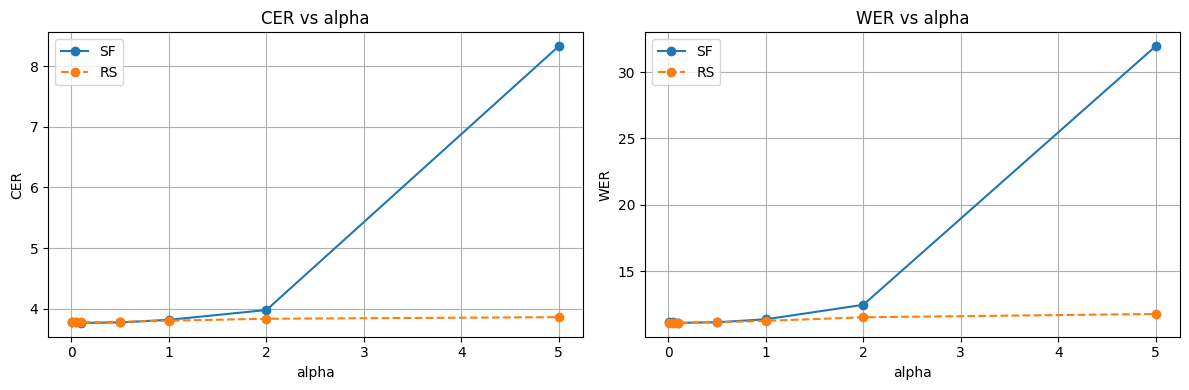

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

sf = pd.DataFrame(results_lm)
rs = pd.DataFrame(results_rescore)

sf_mean = sf.groupby("alpha")[["WER", "CER"]].mean()
rs_mean = rs.groupby("alpha")[["WER", "CER"]].mean()

alphas = sf_mean.index

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- CER ---
axes[0].plot(alphas, sf_mean["CER"], marker='o', label="SF")
axes[0].plot(alphas, rs_mean["CER"], marker='o', linestyle='--', label="RS")
axes[0].set_title("CER vs alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("CER")
axes[0].grid()
axes[0].legend()

# --- WER ---
axes[1].plot(alphas, sf_mean["WER"], marker='o', label="SF")
axes[1].plot(alphas, rs_mean["WER"], marker='o', linestyle='--', label="RS")
axes[1].set_title("WER vs alpha")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("WER")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
df_lm = pd.DataFrame(results_lm)
df_rs = pd.DataFrame(results_rescore)

best_lm = df_lm.loc[df_lm["WER"].idxmin()]
best_rs = df_rs.loc[df_rs["WER"].idxmin()]

print(f"Best SF: alpha={best_lm['alpha']} beta={best_lm['beta']} WER={best_lm['WER']:.2f}%")
print(f"Best RS: alpha={best_rs['alpha']} beta={best_rs['beta']} WER={best_rs['WER']:.2f}%")

decoder = Wav2Vec2Decoder(beam_width=10)

rows = []

for idx, (waveform, sample_rate, ref_text) in enumerate(dataset):
    ref = ref_text.lower().strip()

    inputs = decoder.processor(
        waveform.squeeze().numpy(),
        sampling_rate=sample_rate,
        return_tensors="pt"
    )

    with torch.no_grad():
        logits = decoder.model(**inputs).logits[0]
        logits = logits / decoder.temperature
        log_probs = torch.log_softmax(logits, dim=-1)

    beam = decoder.beam_search_decode(log_probs)

    decoder.alpha = float(best_lm["alpha"])
    decoder.beta = float(best_lm["beta"])
    sf = decoder.beam_search_with_lm(log_probs)

    decoder.alpha = float(best_rs["alpha"])
    decoder.beta = float(best_rs["beta"])
    beams = decoder.beam_search_decode(log_probs, return_beams=True)
    rs = decoder.lm_rescore(beams)

    if sf == rs:
        continue

    d_beam = Levenshtein.distance(ref, beam)
    d_sf = Levenshtein.distance(ref, sf)
    d_rs = Levenshtein.distance(ref, rs)

    if d_sf < d_rs:
        winner = "SF better"
    elif d_rs < d_sf:
        winner = "RS better"
    else:
        winner = "same distance"

    rows.append({
        "idx": idx,
        "ref": ref,
        "beam": beam,
        "sf": sf,
        "rs": rs,
        "beam_dist": d_beam,
        "sf_dist": d_sf,
        "rs_dist": d_rs,
        "winner": winner,
    })

    if len(rows) == 10:
        break

print(f"Found {len(rows)} examples where SF != RS")




Best SF: alpha=0.1 beta=0.5 WER=11.00%
Best RS: alpha=0.01 beta=1.0 WER=11.10%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Found 8 examples where SF != RS
#14 | SF better
REF :  the kick he had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could
BEAM:  the kickhe had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=1]
SF  :  the kickhe had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=1]
RS  :  the kickhe had received was a fore taste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=2]

#88 | same distance
REF :  no wait another half hour
BEAM:  no where another anda ha

In [15]:
for row in rows:
    print("=" * 120)
    print(f"#{row['idx']} | {row['winner']}")
    print(f"REF :  {row['ref']}")
    print(f"BEAM:  {row['beam']}   [dist={row['beam_dist']}]")
    print(f"SF  :  {row['sf']}   [dist={row['sf_dist']}]")
    print(f"RS  :  {row['rs']}   [dist={row['rs_dist']}]")
    print()

#14 | SF better
REF :  the kick he had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could
BEAM:  the kickhe had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=1]
SF  :  the kickhe had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=1]
RS  :  the kickhe had received was a fore taste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could   [dist=2]

#88 | same distance
REF :  no wait another half hour
BEAM:  no where another anda half hour   [dist=9]
SF  :  no whe

In [17]:
# os.makedirs("results", exist_ok=True)
df = pd.DataFrame(rows)
df.to_csv("results/rows.csv", index=False)
# results_rescore =  pd.read_csv("results/results_rescore.csv")


# Таска 7

In [15]:
libri_dataset = LibriSpeechDataset("data/librispeech_test_other/manifest.csv")
earnings_dataset = LibriSpeechDataset("data/earnings22_test/manifest.csv")

results_lm = pd.read_csv("results/results_lm.csv")
results_rescore = pd.read_csv("results/results_rescore.csv")

In [16]:

best_lm = (
    pd.DataFrame(results_lm)
    .sort_values(["WER", "CER", "alpha", "beta"])
    .iloc[0]
)

best_rs = (
    pd.DataFrame(results_rescore)
    .sort_values(["WER", "CER", "alpha", "beta"])
    .iloc[0]
)
print(f"Best SF: alpha={best_lm['alpha']} beta={best_lm['beta']}")
print(f"Best RS: alpha={best_rs['alpha']} beta={best_rs['beta']}")

Best SF: alpha=0.1 beta=0.5
Best RS: alpha=0.01 beta=1.0


In [17]:
decoder = Wav2Vec2Decoder(beam_width=10)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [38]:
libri_rows = []

w, c, t = evaluate(decoder, libri_dataset, method="greedy")
libri_rows.append(["Greedy", w * 100, c * 100, t])

w, c, t = evaluate(decoder, libri_dataset, method="beam")
libri_rows.append(["Beam search", w * 100, c * 100, t])

decoder.alpha = float(best_lm["alpha"])
decoder.beta = float(best_lm["beta"])
w, c, t = evaluate(decoder, libri_dataset, method="beam_lm")
libri_rows.append(["Beam + 10-gram (sf)", w * 100, c * 100, t])

decoder.alpha = float(best_rs["alpha"])
decoder.beta = float(best_rs["beta"])
w, c, t = evaluate(decoder, libri_dataset, method="beam_lm_rescore")
libri_rows.append(["Beam + 10-gram (rescoring)", w * 100, c * 100, t])

libri_df = pd.DataFrame(libri_rows, columns=["Method", "LibriSpeech WER", "LibriSpeech CER", "time_sec"])
libri_df.to_csv("results/task7_librispeech.csv", index=False)
libri_df.round(2)

,Method,LibriSpeech WER,LibriSpeech CER,time_sec
0,Greedy,11.22,3.81,93.82
1,Beam search,11.07,3.77,184.40
2,Beam + 10-gram (sf),11.05,3.75,281.45
3,Beam + 10-gram (rescoring),11.10,3.76,171.25


In [39]:
earnings_rows = []

w, c, t = evaluate(decoder, earnings_dataset, method="greedy")
earnings_rows.append(["Greedy", w * 100, c * 100, t])

w, c, t = evaluate(decoder, earnings_dataset, method="beam")
earnings_rows.append(["Beam search", w * 100, c * 100, t])

decoder.alpha = float(best_lm["alpha"])
decoder.beta = float(best_lm["beta"])
w, c, t = evaluate(decoder, earnings_dataset, method="beam_lm")
earnings_rows.append(["Beam + 10-gram (sf)", w * 100, c * 100, t])

decoder.alpha = float(best_rs["alpha"])
decoder.beta = float(best_rs["beta"])
w, c, t = evaluate(decoder, earnings_dataset, method="beam_lm_rescore")
earnings_rows.append(["Beam + 10-gram (rescoring)", w * 100, c * 100, t])

earnings_df = pd.DataFrame(earnings_rows, columns=["Method", "Earnings22 WER", "Earnings22 CER", "time_sec"])
earnings_df.round(2)
earnings_df.to_csv("results/task7_earnings22.csv", index=False)

In [21]:
# libri_df = pd.read_csv("results/task7_librispeech.csv")
# earnings_df = pd.read_csv("results/task7_earnings22.csv")

In [40]:
task7_table = libri_df.merge(earnings_df, on="Method")
task7_table = task7_table[["Method", "LibriSpeech WER", "LibriSpeech CER", "Earnings22 WER", "Earnings22 CER"]]
task7_table.round(2)

,Method,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
0,Greedy,11.22,3.81,54.97,25.58
1,Beam search,11.07,3.77,54.94,25.38
2,Beam + 10-gram (sf),11.05,3.75,55.57,25.48
3,Beam + 10-gram (rescoring),11.10,3.76,55.21,25.38


# Таска 7 Б

In [41]:
results_lm = pd.read_csv("results/results_lm.csv")
best_lm = (pd.DataFrame(results_lm).sort_values(["WER", "CER", "alpha", "beta"]).iloc[0])

In [24]:
earnings_dataset = LibriSpeechDataset("data/earnings22_test/manifest.csv")
decoder = Wav2Vec2Decoder(beam_width=10)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [26]:
temps = [0.5, 1.0, 1.5, 2.0]
task7b_rows = []
for temp in temps:
    decoder.temperature = temp

    w, c, t = evaluate(decoder, earnings_dataset, method="greedy")
    task7b_rows.append(["Greedy", temp, w * 100, c * 100, t])

    decoder.alpha = float(best_lm["alpha"])
    decoder.beta = float(best_lm["beta"])
    w, c, t = evaluate(decoder, earnings_dataset, method="beam_lm")
    task7b_rows.append(["Beam + 10-gram (shallow fusion)", temp, w * 100, c * 100, t])

task7b_df = pd.DataFrame(
    task7b_rows,
    columns=["Method", "Temperature", "WER", "CER", "time_sec"]
).round(2)

task7b_df.to_csv("results/task7b_earnings22_temperature.csv", index=False)
task7b_df

,Method,Temperature,WER,CER,time_sec
0,Greedy,0.5,54.97,25.58,70.70
1,Beam + 10-gram (shallow fusion),0.5,55.18,25.56,217.95
2,Greedy,1.0,54.97,25.58,70.77
3,Beam + 10-gram (shallow fusion),1.0,55.36,25.43,213.84
4,Greedy,1.5,54.97,25.58,71.68
5,Beam + 10-gram (shallow fusion),1.5,56.17,25.56,222.62
6,Greedy,2.0,54.97,25.58,78.96
7,Beam + 10-gram (shallow fusion),2.0,57.71,25.81,215.40


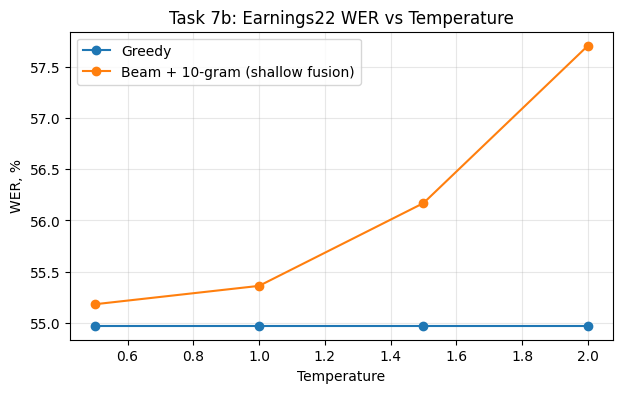

In [27]:
plt.figure(figsize=(7, 4))

for method in task7b_df["Method"].unique():
    part = task7b_df[task7b_df["Method"] == method]
    plt.plot(part["Temperature"], part["WER"], marker="o", label=method)

plt.xlabel("Temperature")
plt.ylabel("WER, %")
plt.title("Task 7b: Earnings22 WER vs Temperature")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Таска 9

In [42]:
libri_dataset = LibriSpeechDataset("data/librispeech_test_other/manifest.csv")
earnings_dataset = LibriSpeechDataset("data/earnings22_test/manifest.csv")

In [43]:
# лучшая модель из  RS
results_rescore = pd.read_csv("results/results_rescore.csv")
best_rs = pd.DataFrame(results_rescore).sort_values(["WER", "CER", "alpha", "beta"]).iloc[0]

In [58]:
decoder_libri_rs = Wav2Vec2Decoder(
    beam_width=10,
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    alpha=float(best_rs["alpha"]),
    beta=float(best_rs["beta"]),
)

decoder_fin_rs = Wav2Vec2Decoder(
    beam_width=10,
    lm_model_path="lm/financial-3gram.binary",
    alpha=1,
    beta=1,
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [59]:
rows_task9 = []

In [60]:
# считаем де модели и 2 датасета
w, c, t = evaluate(decoder_libri_rs, libri_dataset, method="beam_lm_rescore")
rows_task9.append(["LibriSpeech", "LibriSpeech 3-gram", w * 100, c * 100, t])

w, c, t = evaluate(decoder_fin_rs, libri_dataset, method="beam_lm_rescore")
rows_task9.append(["LibriSpeech", "Financial 3-gram", w * 100, c * 100, t])

w, c, t = evaluate(decoder_libri_rs, earnings_dataset, method="beam_lm_rescore")
rows_task9.append(["Earnings22", "LibriSpeech 3-gram", w * 100, c * 100, t])

w, c, t = evaluate(decoder_fin_rs, earnings_dataset, method="beam_lm_rescore")
rows_task9.append(["Earnings22", "Financial 3-gram", w * 100, c * 100, t])

In [61]:
task9_df = pd.DataFrame(
    rows_task9,
    columns=["Dataset", "LM", "WER", "CER", "time_sec"]
).round(2)

task9_df.to_csv("results/task9_results.csv", index=False)


In [62]:
task9_table = task9_df.pivot(index="Dataset", columns="LM", values=["WER", "CER"]).round(2)
task9_table

WER                                 CER  \
LM          Financial 3-gram LibriSpeech 3-gram Financial 3-gram   
Dataset                                                            
Earnings22             52.95              55.21            25.05   
LibriSpeech            11.83              11.10             3.86   

                                
LM          LibriSpeech 3-gram  
Dataset                         
Earnings22               25.38  
LibriSpeech               3.76